# Análise Exploratória de Dados — Churn Bancário

## Objetivo
Entender o perfil dos clientes que abandonam o banco (churn),
identificando padrões e variáveis relevantes para a modelagem preditiva.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

print("Bibliotecas carregadas com sucesso!")

Bibliotecas carregadas com sucesso!


## 1. Carregando os Dados

In [3]:
df = pd.read_csv('../data/raw/train.csv')
print(f"Dataset carregado: {df.shape[0]} linhas e {df.shape[1]} colunas")

Dataset carregado: 165034 linhas e 14 colunas


## 2. Primeiras Impressões

In [4]:
df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1.0,0.0,181449.97,0
1,1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1.0,1.0,49503.50,0
2,2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1.0,0.0,184866.69,0
3,3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1.0,1.0,84560.88,0
4,4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1.0,1.0,15068.83,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165034 entries, 0 to 165033
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id               165034 non-null  int64  
 1   CustomerId       165034 non-null  int64  
 2   Surname          165034 non-null  object 
 3   CreditScore      165034 non-null  int64  
 4   Geography        165034 non-null  object 
 5   Gender           165034 non-null  object 
 6   Age              165034 non-null  float64
 7   Tenure           165034 non-null  int64  
 8   Balance          165034 non-null  float64
 9   NumOfProducts    165034 non-null  int64  
 10  HasCrCard        165034 non-null  float64
 11  IsActiveMember   165034 non-null  float64
 12  EstimatedSalary  165034 non-null  float64
 13  Exited           165034 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 17.6+ MB


In [6]:
df.describe()

,id,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,165034.0000,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,82516.5000,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,47641.3565,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,0.0000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41258.2500,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,82516.5000,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,123774.7500,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,165033.0000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


## 3. Verificando Valores Nulos e Duplicatas

In [7]:
print("Valores nulos por coluna:")
print(df.isnull().sum())
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")

Valores nulos por coluna:
id                 0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Linhas duplicadas: 0


## 4. Análise da Variável Alvo (Churn)

Distribuição do Churn:
Ficou (0): 130,113 clientes (78.8%)
Saiu  (1): 34,921 clientes (21.2%)


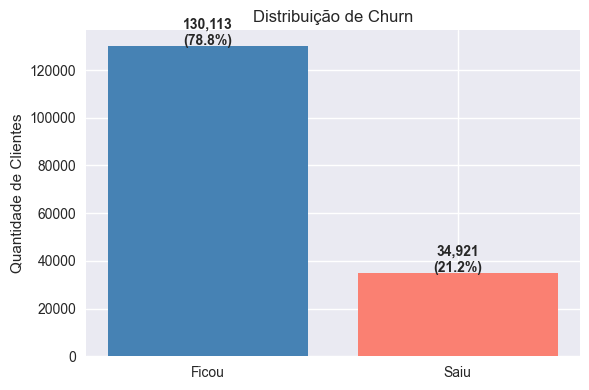

In [8]:
churn_counts = df['Exited'].value_counts()
churn_pct = df['Exited'].value_counts(normalize=True) * 100

print("Distribuição do Churn:")
print(f"Ficou (0): {churn_counts[0]:,} clientes ({churn_pct[0]:.1f}%)")
print(f"Saiu  (1): {churn_counts[1]:,} clientes ({churn_pct[1]:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Ficou', 'Saiu'], churn_counts, color=['steelblue', 'salmon'])
ax.set_title('Distribuição de Churn')
ax.set_ylabel('Quantidade de Clientes')
for i, v in enumerate(churn_counts):
    ax.text(i, v + 500, f'{v:,}\n({churn_pct[i]:.1f}%)', 
            ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Análise das Variáveis Numéricas

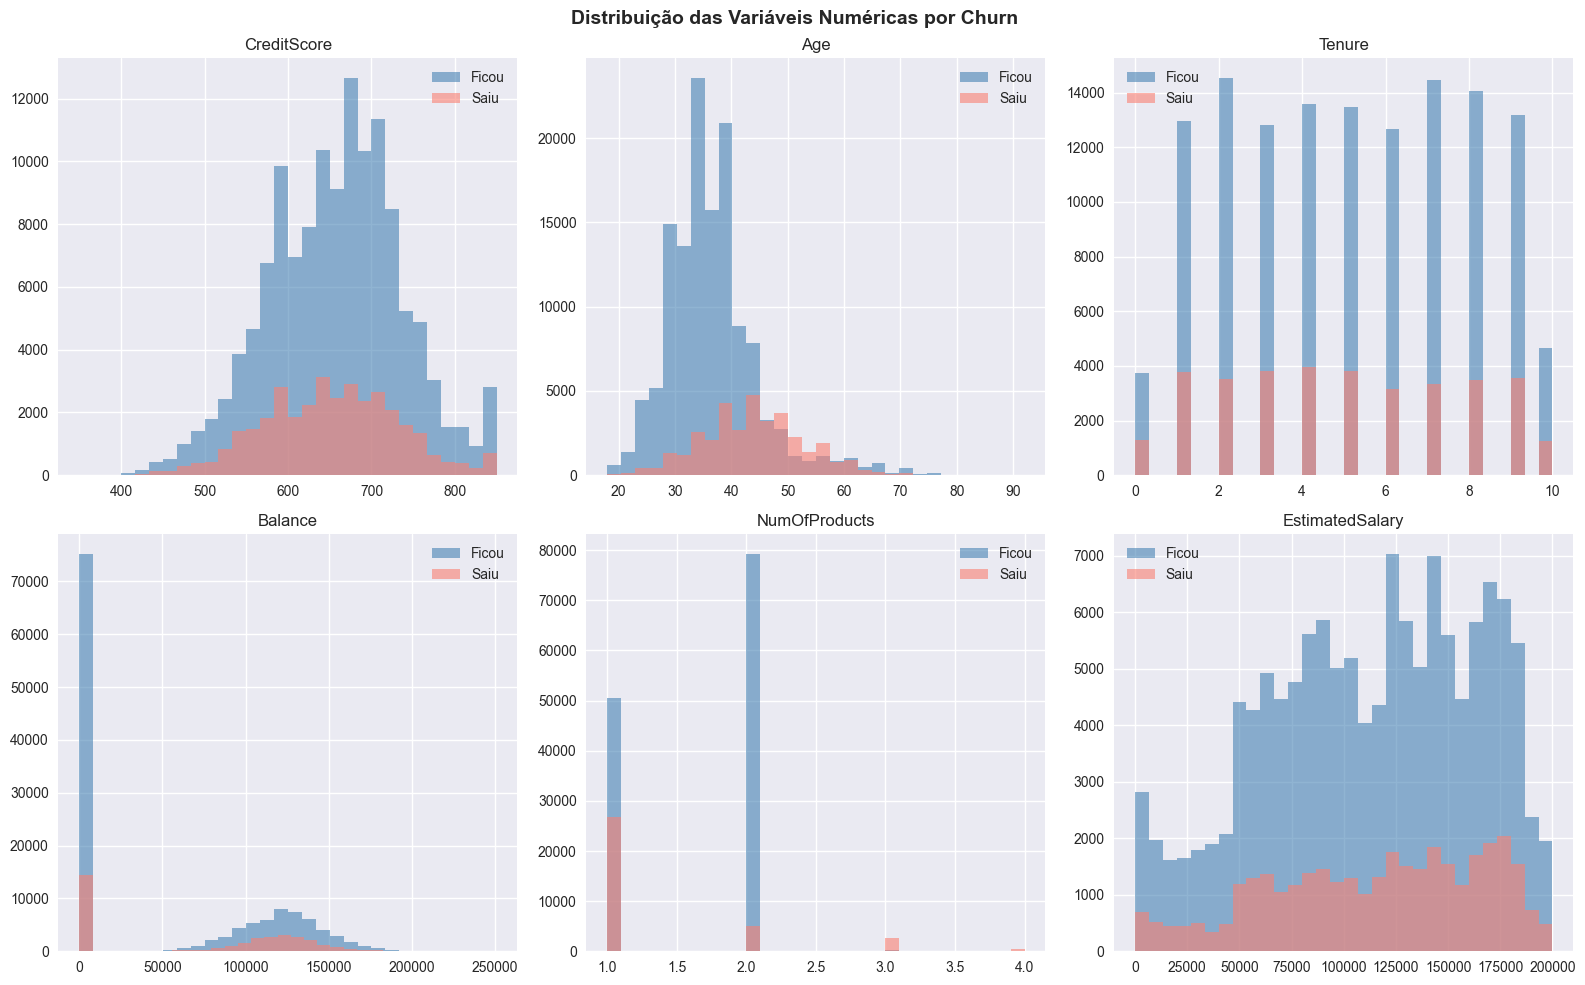

In [9]:
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 
            'NumOfProducts', 'EstimatedSalary']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[df['Exited']==0][col], bins=30, 
                 alpha=0.6, label='Ficou', color='steelblue')
    axes[i].hist(df[df['Exited']==1][col], bins=30, 
                 alpha=0.6, label='Saiu', color='salmon')
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Distribuição das Variáveis Numéricas por Churn', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Análise das Variáveis Categóricas

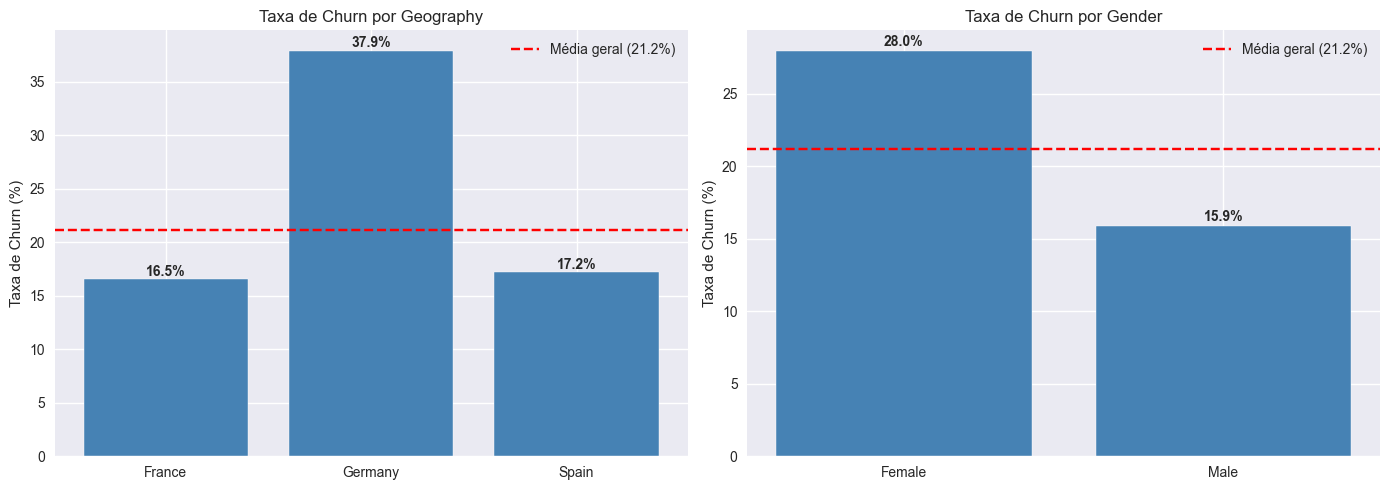

In [10]:
cat_cols = ['Geography', 'Gender']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)['Exited'].mean() * 100
    bars = axes[i].bar(churn_rate.index, churn_rate.values, 
                       color='steelblue', edgecolor='white')
    axes[i].set_title(f'Taxa de Churn por {col}')
    axes[i].set_ylabel('Taxa de Churn (%)')
    axes[i].axhline(y=df['Exited'].mean()*100, color='red', 
                    linestyle='--', label=f'Média geral ({df["Exited"].mean()*100:.1f}%)')
    axes[i].legend()
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, 
                     bar.get_height() + 0.3, f'{val:.1f}%', 
                     ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Correlação entre Variáveis

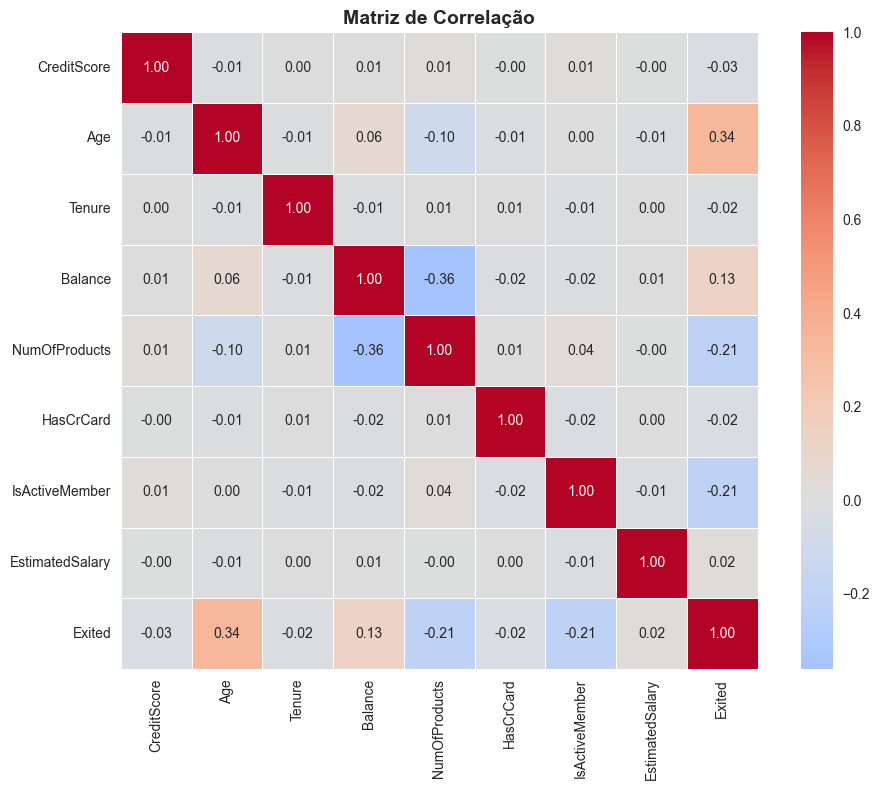

In [11]:
plt.figure(figsize=(10, 8))
corr = df[['CreditScore', 'Age', 'Tenure', 'Balance', 
           'NumOfProducts', 'HasCrCard', 
           'IsActiveMember', 'EstimatedSalary', 'Exited']].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlação', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Insights Finais

In [12]:
print("""
PRINCIPAIS INSIGHTS DO EDA
===========================

1. TAXA DE CHURN: 21.2% dos clientes saíram
   → Dataset desbalanceado, precisará de tratamento na modelagem

2. IDADE: Principal variável correlacionada com churn (0.34)
   → Clientes entre 40-60 anos têm maior propensão a sair

3. NÚMERO DE PRODUTOS: Relação não-linear importante
   → 1-2 produtos: churn baixo
   → 3-4 produtos: churn altíssimo (quase 100%)

4. GEOGRAFIA: Alemanha com 37.9% de churn
   → Quase o dobro da média geral (21.2%)

5. GÊNERO: Mulheres com 28% vs Homens com 15.9%
   → Diferença significativa acima da média

6. MEMBROS ATIVOS: Correlação negativa (-0.21)
   → Clientes ativos churnam menos

7. VARIÁVEIS COM BAIXO PODER PREDITIVO:
   → CreditScore, Tenure, EstimatedSalary
""")


PRINCIPAIS INSIGHTS DO EDA

1. TAXA DE CHURN: 21.2% dos clientes saíram
   → Dataset desbalanceado, precisará de tratamento na modelagem

2. IDADE: Principal variável correlacionada com churn (0.34)
   → Clientes entre 40-60 anos têm maior propensão a sair

3. NÚMERO DE PRODUTOS: Relação não-linear importante
   → 1-2 produtos: churn baixo
   → 3-4 produtos: churn altíssimo (quase 100%)

4. GEOGRAFIA: Alemanha com 37.9% de churn
   → Quase o dobro da média geral (21.2%)

5. GÊNERO: Mulheres com 28% vs Homens com 15.9%
   → Diferença significativa acima da média

6. MEMBROS ATIVOS: Correlação negativa (-0.21)
   → Clientes ativos churnam menos

7. VARIÁVEIS COM BAIXO PODER PREDITIVO:
   → CreditScore, Tenure, EstimatedSalary

